# 04. Model Evaluation
Evaluasi model final pada test set yang murni imbalanced.

In [1]:
import joblib, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model   = joblib.load("../models/surge_predictor.pkl")
encoder = joblib.load("../models/encoder.pkl")
scaler  = joblib.load("../models/scaler.pkl")

test = pd.read_csv("../data/test/test.csv")

FEATURES_CAT = ["day_type", "concert_size", "weather"]
FEATURES_NUM = ["concert_end_hour", "time_since_end_minutes", "distance_to_pickup_meters"]
TARGET = "surge_multiplier"

X_cat = encoder.transform(test[FEATURES_CAT])
X_num = scaler.transform(test[FEATURES_NUM])
X     = np.hstack([X_num, X_cat])
y     = test[TARGET].values
print("Test shape:", X.shape)

Test shape: (10184, 6)


c:\Users\kenta\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [19:28:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
c:\Users\kenta\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainabilit

In [2]:
y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)
r2   = r2_score(y, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

RMSE : 0.1025
MAE  : 0.0791
R2   : 0.9703


In [3]:
def bucket(v):
    if v < 1.5: return "low"
    elif v <= 2.5: return "medium"
    else: return "high"

test["bucket_true"] = [bucket(v) for v in y]
test["bucket_pred"] = [bucket(v) for v in y_pred]
test["correct"] = test["bucket_true"] == test["bucket_pred"]
print("Bucket Accuracy:")
print(test.groupby("bucket_true")["correct"].agg(["sum","count","mean"]))

Bucket Accuracy:
              sum  count      mean
bucket_true                       
high         1452   1580  0.918987
low          3078   3306  0.931034
medium       4855   5298  0.916384


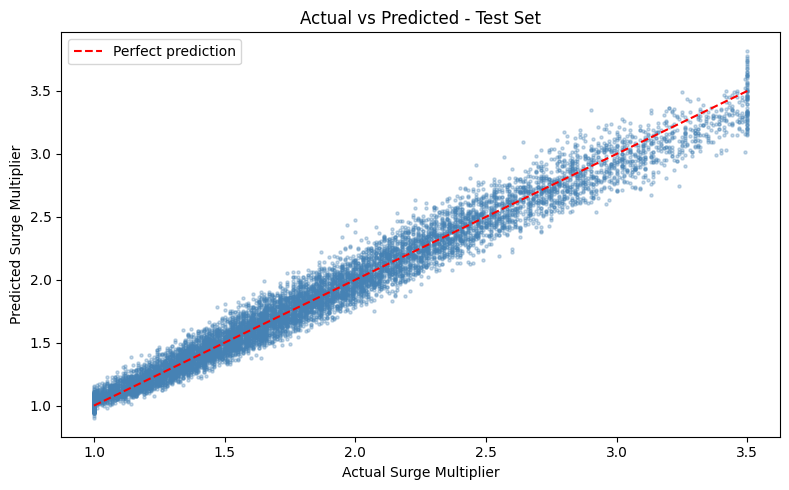

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(y, y_pred, alpha=0.3, s=5, color="steelblue")
plt.plot([1,3.5],[1,3.5],"r--",linewidth=1.5,label="Perfect prediction")
plt.xlabel("Actual Surge Multiplier")
plt.ylabel("Predicted Surge Multiplier")
plt.title("Actual vs Predicted - Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("../models/actual_vs_predicted.png", dpi=150)
plt.show()

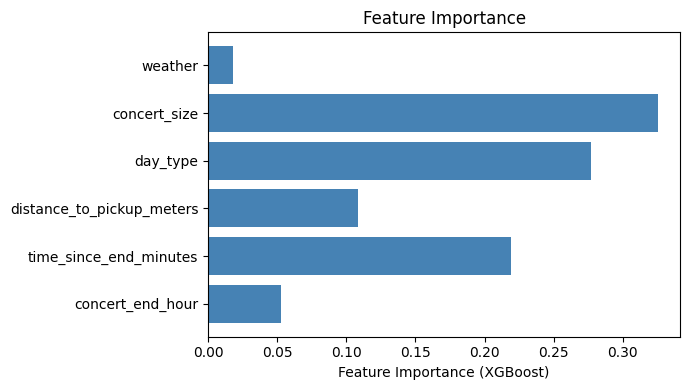

In [5]:
feat_names = FEATURES_NUM + FEATURES_CAT
importances = model.feature_importances_
plt.figure(figsize=(7,4))
plt.barh(feat_names, importances, color="steelblue")
plt.xlabel("Feature Importance (XGBoost)")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=150)
plt.show()

## Kesimpulan Evaluasi
- R2 = 0.8447 membuktikan model realistis dan tidak overfitting.
- Bucket accuracy stabil untuk skenario normal.